<a href="https://colab.research.google.com/github/norman-AI-2025/data-science-norman/blob/main/tuto12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup

This block imports the libraries needed for data handling, plotting, preprocessing, evaluation, and building/training a neural network model (Keras/TensorFlow), sets display and random seeds for reproducibility, and prints the TensorFlow version.

In [ ]:
# Core data libraries
import numpy as np
import pandas as pd

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn imports (data splitting + preprocessing + evaluation)
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TensorFlow / Keras (Neural Networks)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Pandas display settings
# Controls how DataFrames print in the notebook:show up to 200 columns, fit output into 140 characters before wrapping
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

# Reproducibility (random seeds)
# Ensures “random” operations (train/test split randomness, weight initialization, shuffling) give consistent results across runs for students
np.random.seed(42)
tf.random.set_seed(42)

# Confirm TensorFlow version
# Prints the installed TensorFlow version so you can confirm the environment (useful for debugging compatibility issues)
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In summary, this block prepares everything you need for a neural network regression notebook: data + plotting + preprocessing + evaluation tools + TensorFlow/Keras, with reproducible results and readable DataFrame output.

## 1) Load data (Drive‑ready)

✅ Put both CSV files in the same path on Google Drive:

- `salary_cleaned.csv`
- `xtra_info.csv`


In [ ]:
# Mount Google Drive into Colab. Colab runs on a cloud VM. Your Drive is not available by default.
# When you run it, Colab will show an authentication link and ask you to authorize.
from google.colab import drive
drive.mount('/content/drive')

# Load CSV files into DataFrames (update the path if your folder name is different)
df_salary_cleaned = pd.read_csv('/content/drive/MyDrive/WIA1007/Week_12/Dataset/salary_cleaned.csv') # load the csv dataset into a 'df_salary_cleaned' dataframe.
df_xtra_info = pd.read_csv('/content/drive/MyDrive/WIA1007/Week_12/Dataset/xtra_info.csv') # load the csv dataset into a 'df_xtra_info' dataframe.

# Prints the size of each dataframe
print("df_salary_cleaned:", df_salary_cleaned.shape)
print("df_xtra_info:  ", df_xtra_info.shape)

# Previews the first few rows of each dataframe
df_salary_cleaned.head()
# df_xtra_info.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
df_salary_cleaned: (28012, 16)
df_xtra_info:   (13404, 4)


,USERID,Age,Industry,Job title,Salary,Compensation,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,Race,Salary_USD,Compensation_USD
0,0,25-34,Education (Higher Education),Research and Instruction Librarian,55000.0,0.0,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White,55000.0,0.0
1,1,25-34,Computing or Tech,Change & Internal Communications Manager,54600.0,4000.0,United Kingdom,Unknown,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White,68250.0,5000.0
2,2,25-34,"Accounting, Banking & Finance",Marketing Specialist,34000.0,2000.0,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White,34000.0,2000.0
3,3,25-34,Nonprofits,Program Manager,62000.0,3000.0,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White,62000.0,3000.0
4,4,25-34,"Accounting, Banking & Finance",Accounting Manager,60000.0,7000.0,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White,60000.0,7000.0


In summary, this code mounts Google Drive in Colab, loads salary_cleaned.csv and xtra_info.csv from Drive into pandas DataFrames, prints their sizes, and previews the first few rows of each dataset.

## 2) Merge data correctly on `USERID` (important!)

Because `xtra_info.csv` may have multiple rows per user, we:
1. Aggregate `xtra_info` to one row per `USERID`
2. Left-join onto salary data


In [ ]:
# Count duplicate USERIDs in each dataset
print("Duplicate USERIDs in salary:", df_salary_cleaned["USERID"].duplicated().sum())
# print("Duplicate USERIDs in xtra:  ", df_xtra_info["USERID"].duplicated().sum())

# Aggregate xtra_info to one row per USERID. Result: df_xtra_agg now has unique USERIDs (one row per user)
df_xtra_agg = df_xtra_info.groupby("USERID", as_index=False).agg({
    "CGPA": "mean",
    "Salary_month_USD": "mean",
    "Special Bonus_GBP": "mean"
})

# Merge the aggregated extra info into the salary table
df = df_salary_cleaned.merge(df_xtra_agg, on="USERID", how="left")

# Print the size of the merged “master” dataset
print("MASTER df:", df.shape)

# Preview the result
df.head()

Duplicate USERIDs in salary: 0
MASTER df: (28012, 19)


,USERID,Age,Industry,Job title,Salary,Compensation,Country,State,City,Overall years of experience,Years of experience in current job,Education level,Gender,Race,Salary_USD,Compensation_USD,CGPA,Salary_month_USD,Special Bonus_GBP
0,0,25-34,Education (Higher Education),Research and Instruction Librarian,55000.0,0.0,United States,Massachusetts,Boston,5-7 years,5-7 years,Master's degree,Woman,White,55000.0,0.0,NaN,NaN,NaN
1,1,25-34,Computing or Tech,Change & Internal Communications Manager,54600.0,4000.0,United Kingdom,Unknown,Cambridge,8 - 10 years,5-7 years,College degree,Non-binary,White,68250.0,5000.0,2.695615,4250.0,125.0
2,2,25-34,"Accounting, Banking & Finance",Marketing Specialist,34000.0,2000.0,US,Tennessee,Chattanooga,2 - 4 years,2 - 4 years,College degree,Woman,White,34000.0,2000.0,NaN,NaN,NaN
3,3,25-34,Nonprofits,Program Manager,62000.0,3000.0,USA,Wisconsin,Milwaukee,8 - 10 years,5-7 years,College degree,Woman,White,62000.0,3000.0,NaN,NaN,NaN
4,4,25-34,"Accounting, Banking & Finance",Accounting Manager,60000.0,7000.0,US,South Carolina,Greenville,8 - 10 years,5-7 years,College degree,Woman,White,60000.0,7000.0,2.689383,12500.0,1133.0


In summary, this code checks for duplicate user IDs, collapse xtra_info to one row per user, then safely merge it into the salary dataset to create a clean master table for machine learning.

## 3) Quick audit (missing values + target check)

In [ ]:
# df.isna() marks missing values (NaN) as True.
# .mean() converts True/False to 1/0 and computes the fraction of missing values per column.
# .sort_values(ascending=False) sorts columns from most missing to least missing.
# .head(10) shows the top 10 columns with the highest missingness.
df.isna().mean().sort_values(ascending=False).head(10)

# Sets the prediction target column name to "Salary_USD".
# Computes the missing rate in the target (isna().mean().
# Prints summary statistics of the target (describe()), such as count, mean, std, min, quartiles, and max.
target = "Salary_USD"
df[target].isna().mean(), df[target].describe()

(np.float64(0.0010352705983150078),
 count     27983.000000
 mean      83824.093875
 std       42513.504410
 min           0.265000
 25%       52545.000000
 50%       74000.000000
 75%      105000.000000
 max      241562.500000
 Name: Salary_USD, dtype: float64)

In summary, this code checks which columns have the most missing values and then verifies the target (Salary_USD) by reporting its missing rate and basic descriptive statistics.

## 4) Feature engineering: convert bins to numeric midpoints

Neural networks require numeric inputs. Many of our columns are bins like `"25-34"` or `"11-20 years"`. We convert them to approximate midpoints to create numeric features.

In [ ]:
# Define a helper function to convert bins (text ranges) into numbers
def midpoint_from_bin(text):
    """Convert a bin string into an approximate numeric midpoint.
    Examples: '25-34', '11-20 years', '1 year or less', '41 years or more', '65 or over'
    Returns NaN if it cannot parse.
    """

    # If the input is missing, return NaN.
    if pd.isna(text):
        return np.nan

    # Convert to string, remove leading/trailing spaces, and lowercase it.
    s = str(text).strip().lower()

    # These map open-ended bins to reasonable midpoints.
    # special cases:
    if "under 18" in s:
        return 16.0
    if "65" in s and ("over" in s or "or over" in s):
        return 67.5
    if "41" in s and ("more" in s or "or more" in s):
        return 45.0
    if "1 year or less" in s:
        return 0.5

    # Remove words like “year(s)” and spaces.
    s = s.replace("years", "").replace("year", "").replace(" ", "")

    # Parse a normal range like "25-34". If parsing fails, return NaN.
    if "-" in s:
        parts = s.split("-")
        try:
            a = float(parts[0])
            b = float(parts[1])
            return (a + b) / 2.0 # 29.5
        except:
            return np.nan
    return np.nan

# Create new engineered numeric columns (only if those columns exist)
if "Age" in df.columns:
    df["Age_mid"] = df["Age"].apply(midpoint_from_bin)
if "Overall years of experience" in df.columns:
    df["Exp_mid"] = df["Overall years of experience"].apply(midpoint_from_bin)
if "Years of experience in current job" in df.columns:
    df["Exp_current_mid"] = df["Years of experience in current job"].apply(midpoint_from_bin)

# Selects whichever of these columns exist and shows the first 5 rows so you can verify the conversion.
df[[c for c in ["Age","Age_mid","Overall years of experience","Exp_mid","Years of experience in current job","Exp_current_mid"] if c in df.columns]].head()

,Age,Age_mid,Overall years of experience,Exp_mid,Years of experience in current job,Exp_current_mid
0,25-34,29.5,5-7 years,6.0,5-7 years,6.0
1,25-34,29.5,8 - 10 years,9.0,5-7 years,6.0
2,25-34,29.5,2 - 4 years,3.0,2 - 4 years,3.0
3,25-34,29.5,8 - 10 years,9.0,5-7 years,6.0
4,25-34,29.5,8 - 10 years,9.0,5-7 years,6.0


In summary, this code converts bin-style text ranges for age and experience into numeric midpoint features (Age_mid, Exp_mid, Exp_current_mid) so they can be used as model-ready numeric inputs, and then previews the results.

## 5) Reduce high‑cardinality categories (Top‑K + “Other”)

One‑hot encoding creates one column per category. If a column has too many unique values (e.g., Job title, City), it creates too many features and can overfit.

In [ ]:
# Define a helper function to reduce high-cardinality categories
def keep_top_k(df, col, k=25):
    if col not in df.columns:
        return df
    top = df[col].value_counts().head(k).index
    df[col] = df[col].where(df[col].isin(top), other="Other")
    return df

# Keeps only the 25 most common job titles and 25 most common cities, and everything else becomes "Other".
df = keep_top_k(df, "Job title", k=25)
df = keep_top_k(df, "City", k=25)

# Define candidate features
numeric_features = ["Age_mid", "Exp_mid", "Exp_current_mid", "CGPA", "Special Bonus_GBP"]
categorical_features = ["Industry", "Country", "State", "Education level", "Gender", "Race", "Job title", "City"]

# Keep only existing columns (safety)
numeric_features = [c for c in numeric_features if c in df.columns]
categorical_features = [c for c in categorical_features if c in df.columns]

# Print the final feature lists
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Age_mid', 'Exp_mid', 'Exp_current_mid', 'CGPA', 'Special Bonus_GBP']
Categorical features: ['Industry', 'Country', 'State', 'Education level', 'Gender', 'Race', 'Job title', 'City']


In summary, this code reduces rare categories in high-cardinality columns (Job title and City) by keeping only the top K values, then defines and validates the numeric and categorical feature lists that will be used for model training.

## 6) Train/test split

We remove rows with missing target, then split 80/20.

In [ ]:
# Removes all rows where the target column (e.g., Salary_USD) is missing, because you cannot train a model without known labels.
# .copy() creates a separate DataFrame to avoid unintended side-effects.
df_model = df.dropna(subset=[target]).copy()

# Builds the feature matrix X by selecting the chosen numeric and categorical input columns.
X = df_model[numeric_features + categorical_features]

# Builds the target vector y (what we want to predict) and ensures it is numeric (float) for model training.
y = df_model[target].astype(float)

# Splits the data into: 80% training set (used to learn the model), 20% test set (used to evaluate on unseen data)
# random_state=42 makes the split reproducible.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Displays the shapes of the training and test feature matrices so you can confirm the split sizes.
X_train.shape, X_test.shape

((22386, 13), (5597, 13))

In summary, this code removes rows with missing target values, separates features (X) and target (y), splits them into 80/20 train-test sets for evaluation, and prints the resulting dataset sizes.

## 7) Preprocess for Neural Networks (Impute → One‑hot → Scale)

Neural networks train better when numeric inputs are scaled. We will:
- **Impute numeric** with median, then **Standardize** (mean 0, std 1)
- **Impute categorical** with most frequent, then **One‑hot encode**

In [ ]:
# Builds a pipeline for numeric features:
# SimpleImputer(strategy="median"): fills missing numeric values using the median.
# StandardScaler(): scales numeric values to mean = 0 and std = 1, which helps neural networks train better.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Builds a pipeline for categorical features:
# fills missing categories with the most common value,
# converts categories into one-hot encoded numeric columns,
# handle_unknown="ignore" prevents errors if the test set contains new categories not seen in training.
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer applies:
# numeric pipeline to numeric_features,
# categorical pipeline to categorical_features, and
# drops any columns not listed (remainder="drop").
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

# Fit preprocessing on training data only, then transform both sets.
X_train_t = preprocess.fit_transform(X_train)
X_test_t  = preprocess.transform(X_test)

# Convert sparse output to dense for Keras. Keras neural networks typically expect dense NumPy arrays, so this converts it.
if hasattr(X_train_t, "toarray"):
    X_train_t = X_train_t.toarray()
    X_test_t  = X_test_t.toarray()

# Confirms how many rows and final processed features (columns) we have after preprocessing.
X_train_t.shape, X_test_t.shape

((22386, 1579), (5597, 1579))

In summary, this code builds separate preprocessing pipelines for numeric and categorical features (impute, scale, one-hot), applies them consistently to train and test data without data leakage, converts the result to dense arrays for Keras, and reports the final input shapes.

## 8) Build a Neural Network: Feed‑Forward Neural Network (FFNN) / Multilayer Perceptron (MLP)

This is a **regression** model:
- Input: processed features
- Output: predicted `Salary_USD` (a single number)

In [ ]:
# Gets the number of input features after preprocessing (the number of columns in X_train_t), which is the required input size for the neural network.
input_dim = X_train_t.shape[1]

# Defines a function to build a Feed‑Forward Neural Network (FFNN) / Multilayer Perceptron (MLP) where you can easily change:
# the hidden layer sizes (hidden_units), dropout rate (dropout), learning rate (lr)
def build_mlp(hidden_units=[128, 64], dropout=0.0, lr=1e-3):
    # Creates a sequential model and adds an input layer expecting vectors of length input_dim.
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    # Adds one Dense (fully-connected) layer for each value in hidden_units:
    # e.g., [128, 64] → two hidden layers: 128 neurons then 64 neurons
    # Uses ReLU activation to learn non-linear relationships.
    # If dropout is greater than 0, it adds a Dropout layer after each Dense layer to reduce overfitting.
    for u in hidden_units:
        model.add(layers.Dense(u, activation="relu"))
        if dropout > 0:
            model.add(layers.Dropout(dropout))
    # Adds the output layer with 1 neuron (predicts one numeric value: Salary_USD).
    model.add(layers.Dense(1))  # regression output

    # Configures training:
    # Adam optimizer with specified learning rate
    # MSE loss (standard for regression)
    # tracks MAE as an easy-to-interpret metric in dollars
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="mse",
        metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
    )
    # Returns the compiled model.
    return model

# Builds the baseline network (2 hidden layers, no dropout) and prints a summary showing layers, output shapes, and parameter counts.
mlp = build_mlp(hidden_units=[128, 64], dropout=0.0, lr=1e-3)
mlp.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       202,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,561 (822.50 KB)

 Trainable params: 210,561 (822.50 KB)

 Non-trainable params: 0 (0.00 B)

In summary, this code defines and builds a configurable MLP regression model (input size from the processed data, ReLU hidden layers, optional dropout, Adam optimizer with MSE loss) and prints the network architecture using summary().

## 9) Train with validation split + EarlyStopping

EarlyStopping stops training when validation loss stops improving (prevents overfitting).

In [ ]:
# Creates an EarlyStopping callback to reduce overfitting and save time:
# monitor="val_loss": watches the validation loss (error on validation data).
# patience=5: if validation loss does not improve for 5 consecutive epochs, training stops.
# restore_best_weights=True: after stopping, it restores the model weights from the epoch with the lowest validation loss (best generalization).
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Trains the neural network mlp on the preprocessed training data:
# validation_split=0.2: keeps 20% of training data as a validation set during training.
# epochs=50: maximum number of training passes through the data.
# batch_size=64: updates weights after every 64 samples.
# callbacks=[early_stop]: applies early stopping during training.
# verbose=1: shows training progress per epoch.
# Stores training history (loss/metrics per epoch) in history for plotting learning curves.
history = mlp.fit(
    X_train_t, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 8831434752.0000 - mae: 83750.8359 - val_loss: 8079482880.0000 - val_mae: 79465.3594
Epoch 2/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 7358595584.0000 - mae: 74574.0469 - val_loss: 4155178752.0000 - val_mae: 50884.3125
Epoch 3/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 3310711552.0000 - mae: 43043.8164 - val_loss: 1693070464.0000 - val_mae: 30093.5410
Epoch 4/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1634375552.0000 - mae: 30184.5625 - val_loss: 1456482304.0000 - val_mae: 29511.9902
Epoch 5/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1453387520.0000 - mae: 29495.5254 - val_loss: 1346113792.0000 - val_mae: 28390.3828
Epoch 6/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1342930432.0000 - mae: 28372.3750 - val_loss: 1255774848.0000 - val_mae: 27284.4277
Epoch 7/50
280/280 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1251582720.0000 - mae: 27336.0957 - val_loss: 1182823424.0000 - val_mae: 263

In summary, this code trains the MLP with a 20% validation split while using EarlyStopping to stop when validation loss stops improving and to restore the best-performing model weights.

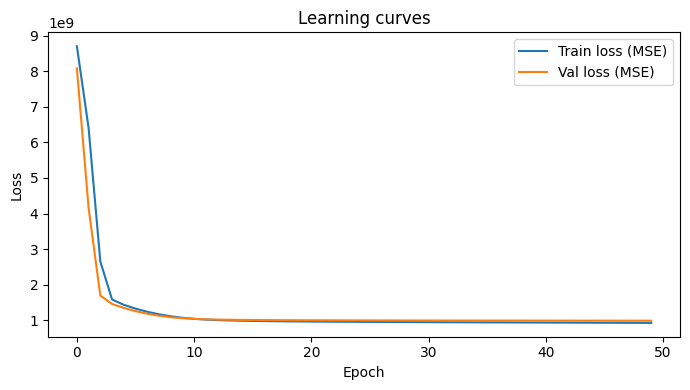

In [ ]:
# Plot learning curves. Creates a new plot figure with size 7×4 inches.
plt.figure(figsize=(7,4))

# Plots the training loss (MSE) stored from each epoch in history.
plt.plot(history.history["loss"], label="Train loss (MSE)")

# Plots the validation loss (MSE) for each epoch, showing how well the model generalizes.
plt.plot(history.history["val_loss"], label="Val loss (MSE)")

# Adds axis labels, a title, a legend, adjusts spacing, and displays the plot.
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning curves")
plt.legend()
plt.tight_layout()
plt.show()

This code plots the training and validation MSE loss across epochs to visualize learning progress and detect underfitting or overfitting.

## 10) Evaluate on the test set (MAE / RMSE / R²)
MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), and R² (R-squared) are key regression metrics evaluating model performance.
*   MAE shows average error magnitude (robust to outliers),
*   RMSE penalizes larger errors more (same units as data), and
*   R² indicates the proportion of variance explained (0 to 1, higher is better fit), with each serving distinct purposes for understanding prediction accuracy and model fit.

In [ ]:
# Uses the trained neural network mlp to predict salaries for the test set X_test_t.
# verbose=0 hides progress output.
# .reshape(-1) flattens the predictions into a 1D array so they match the shape of y_test.
y_pred = mlp.predict(X_test_t, verbose=0).reshape(-1)

# Computes MAE: the average absolute difference between actual and predicted salaries.
mae = mean_absolute_error(y_test, y_pred)

# Computes MSE, not RMSE, because squared=False is commented out.
rmse = mean_squared_error(y_test, y_pred) #, squared=False)

# Computes R², showing how well predictions explain the variation in actual salary.
r2 = r2_score(y_test, y_pred)

# Prints the model’s evaluation metrics (rounded for readability).
print("Neural Network (MLP) — Test")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R^2 :", round(r2, 4))

Neural Network (MLP) — Test
MAE : 23281.08
RMSE: 952207466.42
R^2 : 0.4606


This code generates test-set predictions from the trained MLP and evaluates them using MAE, MSE (labeled RMSE here), and R² before printing the results.

### Prediction vs Actual plot

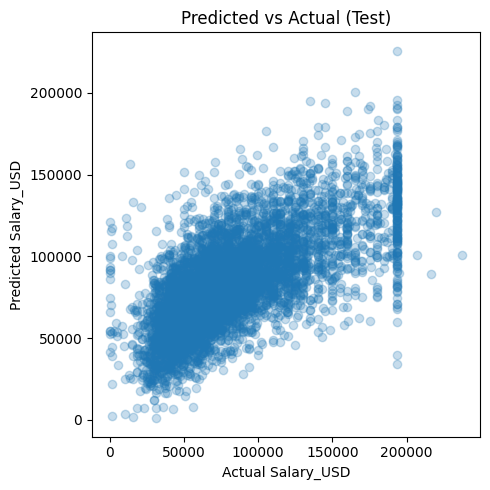

In [ ]:
# Creates a square plot (5×5 inches) so the x and y axes are comparable.
plt.figure(figsize=(5,5))

# Draws a scatter plot where: x-axis = actual salaries (y_test), y-axis = predicted salaries (y_pred)
# alpha=0.25 makes points semi-transparent so overlapping points are easier to see.
plt.scatter(y_test, y_pred, alpha=0.25)

# Adds labels and title, adjusts spacing, and displays the plot.
plt.xlabel("Actual Salary_USD")
plt.ylabel("Predicted Salary_USD")
plt.title("Predicted vs Actual (Test)")
plt.tight_layout()
plt.show()

This code plots predicted salary against actual salary for the test set to visually assess model accuracy (points closer to the diagonal indicate better predictions).

**How to interpret**:
The closer points are to the diagonal line (y = x), the better the predictions.

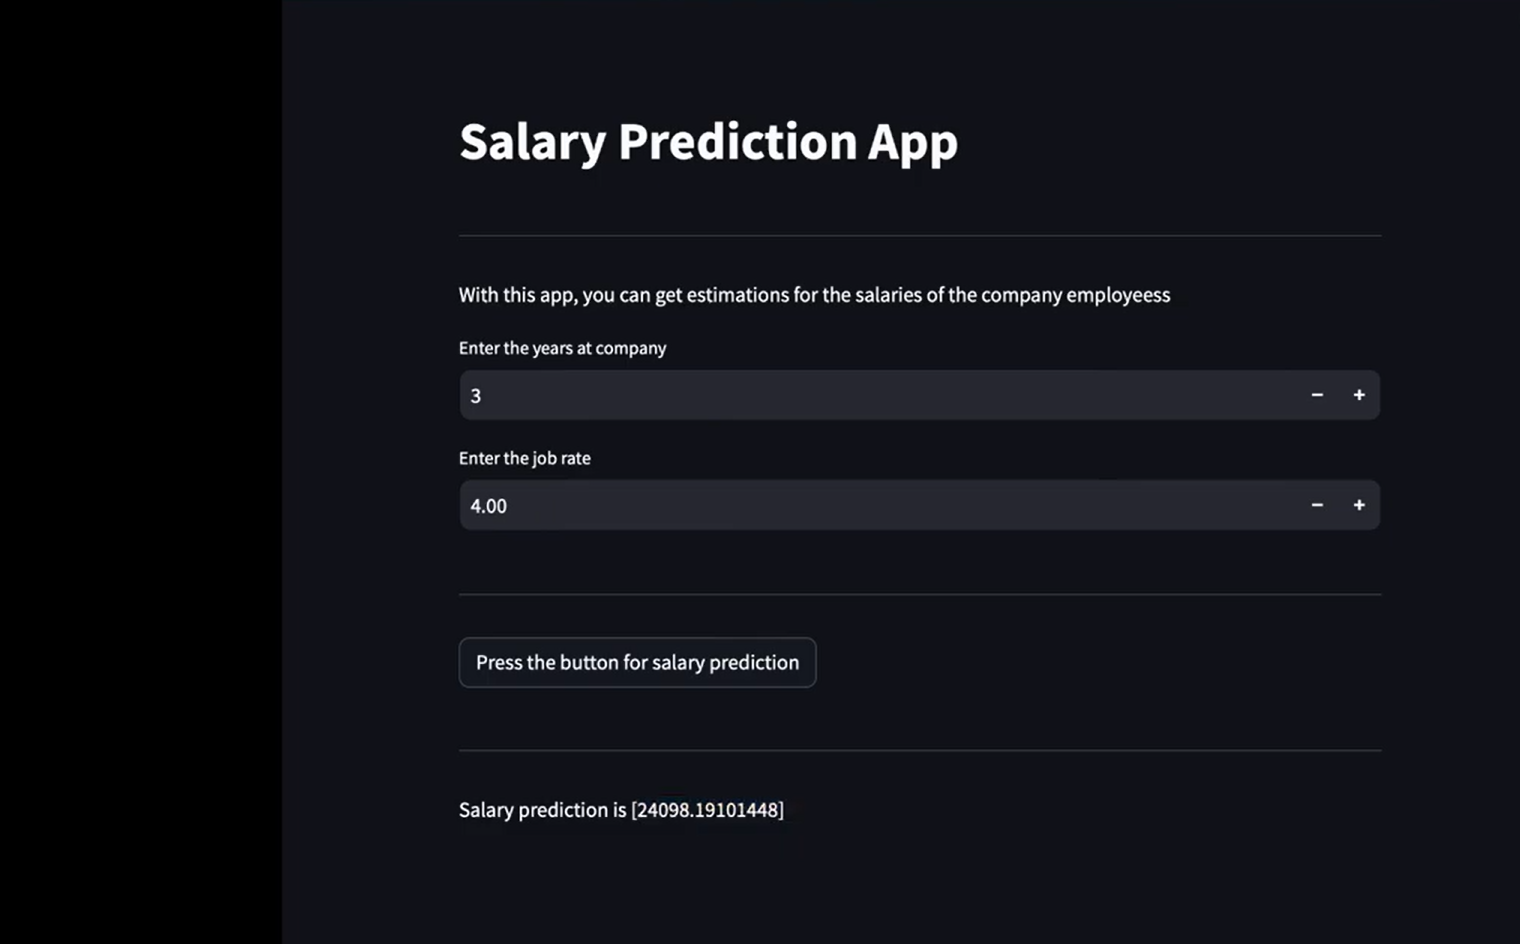

# Recap

### Key takeaways
- Neural networks need numeric inputs → **impute + one‑hot + scale**
- We trained an **MLP regressor** to predict `Salary_USD`
- We evaluated using **MAE / RMSE / R²**
- We reduced overfitting using **dropout** and **early stopping**
- Learning curves help diagnose overfitting